# LLM Evaluation

## Scopo
Valutare e confrontare le performance del modello su due dataset:
- `questions.csv` (MCQ con opzioni A-F)
- `questions_no_hint.csv` (domanda aperta + judge LLM 0/1)

## Input
- API Utopia/Ollama (`/ollama/api/chat`)
- CSV benchmark in `data/`

## Output
- `mcq_results`, `no_hint_results`
- `mcq_summary`, `no_hint_summary`, `comparison_summary`
- dashboard con grafici globali e per livello

In [11]:
import csv
import json
import os
import re
import time
from collections import defaultdict
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import requests

try:
    from IPython.display import display
except Exception:
    display = None

try:
    import pandas as pd
except Exception:
    pd = None

try:
    from dotenv import load_dotenv
except Exception as exc:
    raise RuntimeError(
        "python-dotenv non disponibile nel kernel corrente. Installa con: pip install python-dotenv"
    ) from exc

PROJECT_ROOT = Path("/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite")
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"PROJECT_ROOT non trovato: {PROJECT_ROOT}")

env_loaded_from = None
repo_env = PROJECT_ROOT / ".env"
if repo_env.exists():
    load_dotenv(repo_env, override=False)
    env_loaded_from = repo_env
else:
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / ".env"
        if candidate.exists():
            load_dotenv(candidate, override=False)
            env_loaded_from = candidate
            break

UTOPIA_API_KEY = os.getenv("UTOPIA_API_KEY", "")
if not UTOPIA_API_KEY:
    where = str(env_loaded_from) if env_loaded_from else "nessun .env trovato"
    raise RuntimeError(
        "UTOPIA_API_KEY mancante. Verifica variabile ambiente o file .env. "
        f"Ricerca .env: {where}"
    )

BASE_URL = os.getenv("UTOPIA_BASE_URL", "https://utopia.hpc4ai.unito.it")
API_URL = f"{BASE_URL.rstrip('/')}/ollama/api/chat"

print(
    json.dumps(
        {
            "project_root": str(PROJECT_ROOT),
            "api_url": API_URL,
            "env_loaded_from": str(env_loaded_from) if env_loaded_from else None,
            "pandas_available": pd is not None,
        },
        ensure_ascii=False,
        indent=2,
    )
)

{
  "project_root": "/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite",
  "api_url": "https://utopia.hpc4ai.unito.it/ollama/api/chat",
  "env_loaded_from": "/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/.env",
  "pandas_available": true
}


## Configurazione Runtime

### Scopo
Definire parametri di esecuzione unificati per smoke test e batch.

### Input
- Modelli da env (`UTOPIA_CHAT_MODEL`, opzionale `UTOPIA_JUDGE_MODEL`)
- Paths CSV benchmark

### Output
- Variabili runtime (`START_POS`, `N_QUESTIONS`, `TIMEOUT_SEC`, ecc.)

In [12]:
MCQ_CSV_PATH = PROJECT_ROOT / "data/questions.csv"
NO_HINT_CSV_PATH = PROJECT_ROOT / "data/questions_no_hint.csv"

START_POS = 0
N_QUESTIONS = 100
TIMEOUT_SEC = 120
RUN_SMOKE = True
SMOKE_POS = START_POS

CHAT_MODEL = os.getenv("UTOPIA_CHAT_MODEL", "SLURM.gpt-oss:120b")
JUDGE_MODEL = os.getenv("UTOPIA_JUDGE_MODEL", CHAT_MODEL)

if N_QUESTIONS <= 0:
    raise ValueError(f"N_QUESTIONS deve essere > 0, ricevuto: {N_QUESTIONS}")

for path in (MCQ_CSV_PATH, NO_HINT_CSV_PATH):
    if not path.exists():
        raise FileNotFoundError(f"CSV non trovato: {path}")

HEADERS = {
    "Authorization": f"Bearer {UTOPIA_API_KEY}",
    "Content-Type": "application/json",
}

print(
    json.dumps(
        {
            "mcq_csv": str(MCQ_CSV_PATH),
            "no_hint_csv": str(NO_HINT_CSV_PATH),
            "start_pos": START_POS,
            "n_questions": N_QUESTIONS,
            "timeout_sec": TIMEOUT_SEC,
            "run_smoke": RUN_SMOKE,
            "smoke_pos": SMOKE_POS,
            "chat_model": CHAT_MODEL,
            "judge_model": JUDGE_MODEL,
        },
        ensure_ascii=False,
        indent=2,
    )
)

{
  "mcq_csv": "/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/questions.csv",
  "no_hint_csv": "/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/questions_no_hint.csv",
  "start_pos": 0,
  "n_questions": 100,
  "timeout_sec": 120,
  "run_smoke": true,
  "smoke_pos": 0,
  "chat_model": "SLURM.gpt-oss:120b",
  "judge_model": "SLURM.gpt-oss:120b"
}


## Schemi, Prompt e Utility Core

### Scopo
Centralizzare funzioni comuni per ridurre duplicazioni e migliorare leggibilità.

### Input
- response JSON API
- testo domanda / record allineato

### Output
- funzioni riusabili per parsing, allineamento, scoring e aggregazione

In [13]:
MCQ_SCHEMA = {
    "type": "object",
    "properties": {
        "answer_label": {"type": "string", "enum": ["A", "B", "C", "D", "E", "F"]},
        "short_rationale": {"type": "string"},
    },
    "required": ["answer_label"],
    "additionalProperties": False,
}

NO_HINT_STEP1_SCHEMA = {
    "type": "object",
    "properties": {
        "answer_text": {"type": "string"},
        "short_rationale": {"type": "string"},
    },
    "required": ["answer_text"],
    "additionalProperties": False,
}

JUDGE_SCHEMA = {
    "type": "object",
    "properties": {
        "score": {"type": "integer", "enum": [0, 1]},
        "confidence": {"type": "number", "minimum": 0, "maximum": 1},
        "matched_option_label": {
            "type": "string",
            "enum": ["A", "B", "C", "D", "E", "F", "NONE"],
        },
        "is_semantically_equivalent": {"type": "boolean"},
        "justification": {"type": "string"},
    },
    "required": [
        "score",
        "confidence",
        "matched_option_label",
        "is_semantically_equivalent",
        "justification",
    ],
    "additionalProperties": False,
}


def normalize_space(text: str) -> str:
    return re.sub(r"\s+", " ", (text or "").strip())


def parse_structured_content(response_json: dict[str, Any]) -> dict[str, Any]:
    """Estrae `message.content` e lo converte in dict JSON."""
    raw_content = response_json.get("message", {}).get("content")
    if raw_content is None:
        raise KeyError("response_json['message']['content'] mancante")

    if isinstance(raw_content, str):
        try:
            parsed = json.loads(raw_content)
        except json.JSONDecodeError as exc:
            raise ValueError(f"message.content non parsabile JSON: {raw_content!r}") from exc
    elif isinstance(raw_content, dict):
        parsed = raw_content
    else:
        raise TypeError(f"Tipo inatteso per message.content: {type(raw_content).__name__}")

    if not isinstance(parsed, dict):
        raise TypeError(f"Il JSON structured deve essere object, ricevuto: {type(parsed).__name__}")

    return parsed


def post_structured_chat(
    payload_schema: dict[str, Any],
    prompt: str,
    model: str,
    timeout: int,
) -> dict[str, Any]:
    """Chiamata unica a /ollama/api/chat con output structured."""
    payload = {
        "model": model,
        "messages": [{"role": "user", "content": prompt}],
        "stream": False,
        "format": payload_schema,
        "options": {"temperature": 0},
    }

    response = requests.post(API_URL, headers=HEADERS, json=payload, timeout=timeout)
    if not response.ok:
        raise RuntimeError(f"HTTP {response.status_code} su {API_URL}. Body: {response.text}")

    response_json = response.json()
    structured = parse_structured_content(response_json)
    return {"structured": structured, "response_json": response_json}


def load_valid_rows(csv_path: Path) -> list[dict[str, str]]:
    """Legge CSV e tiene solo righe con `Risposta corretta` valorizzata."""
    with csv_path.open("r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        return [row for row in reader if (row.get("Risposta corretta") or "").strip()]


def extract_mcq_options(mcq_question_text: str) -> dict[str, str]:
    """Estrae opzioni A-F dal testo domanda MCQ."""
    matches = re.findall(r"(?m)^\s*([A-F])\)\s+(.*)$", mcq_question_text or "")
    option_map = {label.strip().upper(): text.strip() for label, text in matches}

    expected = {"A", "B", "C", "D", "E", "F"}
    if set(option_map.keys()) != expected:
        raise ValueError(f"Opzioni MCQ non valide. Trovate: {sorted(option_map.keys())}")

    return option_map


def align_record(pos: int, no_hint_rows: list[dict[str, str]], mcq_rows: list[dict[str, str]]) -> dict[str, Any]:
    """Allinea una domanda no-hint con la corrispondente domanda MCQ (stesso indice su righe valide)."""
    if pos < 0 or pos >= len(no_hint_rows) or pos >= len(mcq_rows):
        raise IndexError(f"pos fuori range: {pos}")

    row_no_hint = no_hint_rows[pos]
    row_mcq = mcq_rows[pos]

    question_no_hint = (row_no_hint.get("Domanda") or "").strip()
    question_mcq_full = (row_mcq.get("Domanda") or "").strip()

    # Lo stem MCQ è tutto prima della prima opzione A)
    stem_match = re.search(r"(?m)^\s*A\)\s+", question_mcq_full)
    question_mcq_stem = question_mcq_full[: stem_match.start()].strip() if stem_match else question_mcq_full

    if normalize_space(question_no_hint) != normalize_space(question_mcq_stem):
        raise RuntimeError(
            "Misallineamento no-hint/MCQ sullo stem. "
            f"pos={pos} | no_hint={question_no_hint!r} | mcq_stem={question_mcq_stem!r}"
        )

    option_map = extract_mcq_options(question_mcq_full)
    correct_label = (row_mcq.get("Risposta corretta") or "").strip().upper()[:1]
    if correct_label not in option_map:
        raise RuntimeError(f"Label corretta non presente nelle opzioni: {correct_label!r}")

    return {
        "pos": pos,
        "qid": (row_mcq.get("#") or str(pos + 1)).strip(),
        "level": (row_no_hint.get("Livello") or "UNKNOWN").strip() or "UNKNOWN",
        "question_no_hint": question_no_hint,
        "question_mcq_full": question_mcq_full,
        "ground_truth_text_no_hint": (row_no_hint.get("Risposta corretta") or "").strip(),
        "ground_truth_label_mcq": correct_label,
        "correct_option_text": option_map[correct_label],
        "option_map": option_map,
    }


def validate_judge_output(obj: dict[str, Any]) -> dict[str, Any]:
    """Valida output judge e ritorna oggetto normalizzato."""
    required = {
        "score",
        "confidence",
        "matched_option_label",
        "is_semantically_equivalent",
        "justification",
    }
    missing = sorted(required - set(obj.keys()))
    if missing:
        raise ValueError(f"Judge output mancante campi required: {missing}")

    score = obj.get("score")
    if score not in (0, 1):
        raise ValueError(f"score non valido: {score!r}")

    confidence = obj.get("confidence")
    if not isinstance(confidence, (int, float)) or not (0 <= float(confidence) <= 1):
        raise ValueError(f"confidence non valida: {confidence!r}")

    matched = obj.get("matched_option_label")
    if matched not in {"A", "B", "C", "D", "E", "F", "NONE"}:
        raise ValueError(f"matched_option_label non valido: {matched!r}")

    if not isinstance(obj.get("is_semantically_equivalent"), bool):
        raise ValueError("is_semantically_equivalent deve essere boolean")

    if not isinstance(obj.get("justification"), str):
        raise ValueError("justification deve essere string")

    return {
        "score": int(score),
        "confidence": float(confidence),
        "matched_option_label": matched,
        "is_semantically_equivalent": obj.get("is_semantically_equivalent"),
        "justification": obj.get("justification").strip(),
    }


def aggregate_by_level(results: list[dict[str, Any]], score_key: str) -> dict[str, dict[str, Any]]:
    """Aggrega metriche per livello usando score binario 0/1 (o None se non giudicato)."""
    by_level: dict[str, dict[str, Any]] = {}

    for row in results:
        level = row.get("level") or "UNKNOWN"
        stats = by_level.setdefault(level, {"n": 0, "judged": 0, "correct": 0, "wrong": 0, "errors": 0})
        stats["n"] += 1

        if row.get("error"):
            stats["errors"] += 1

        score = row.get(score_key)
        if score in (0, 1):
            stats["judged"] += 1
            stats["correct"] += int(score)

    for _, stats in by_level.items():
        stats["wrong"] = max(stats["judged"] - stats["correct"], 0)
        stats["accuracy"] = (stats["correct"] / stats["judged"]) if stats["judged"] else None

    def level_sort_key(level_name: str) -> tuple[int, Any]:
        m = re.match(r"^L(\d+)$", str(level_name).strip().upper())
        return (0, int(m.group(1))) if m else (1, str(level_name))

    return dict(sorted(by_level.items(), key=lambda kv: level_sort_key(kv[0])))


def build_dataset_summary(name: str, results: list[dict[str, Any]], score_key: str) -> dict[str, Any]:
    valid_scores = [int(r[score_key]) for r in results if r.get(score_key) in (0, 1)]
    score_sum = int(sum(valid_scores))
    judged = len(valid_scores)

    return {
        "dataset": name,
        "processed": len(results),
        "judged": judged,
        "score_sum": score_sum,
        "accuracy": (score_sum / judged) if judged else None,
        "errors": sum(1 for r in results if r.get("error")),
        "by_level": aggregate_by_level(results, score_key=score_key),
    }


def build_comparison_table(mcq_summary: dict[str, Any], no_hint_summary: dict[str, Any]) -> dict[str, list[dict[str, Any]]]:
    global_rows = [
        {
            "dataset": "MCQ",
            "processed": mcq_summary["processed"],
            "judged": mcq_summary["judged"],
            "correct": mcq_summary["score_sum"],
            "accuracy": mcq_summary["accuracy"],
            "errors": mcq_summary["errors"],
        },
        {
            "dataset": "No-Hint + Judge",
            "processed": no_hint_summary["processed"],
            "judged": no_hint_summary["judged"],
            "correct": no_hint_summary["score_sum"],
            "accuracy": no_hint_summary["accuracy"],
            "errors": no_hint_summary["errors"],
        },
    ]

    levels = sorted(set(mcq_summary["by_level"]) | set(no_hint_summary["by_level"]))
    level_rows = []
    for level in levels:
        m_stats = mcq_summary["by_level"].get(level, {})
        n_stats = no_hint_summary["by_level"].get(level, {})

        m_acc = m_stats.get("accuracy")
        n_acc = n_stats.get("accuracy")
        delta = (n_acc - m_acc) if (m_acc is not None and n_acc is not None) else None

        level_rows.append(
            {
                "level": level,
                "mcq_correct": m_stats.get("correct", 0),
                "mcq_judged": m_stats.get("judged", 0),
                "mcq_accuracy": m_acc,
                "no_hint_correct": n_stats.get("correct", 0),
                "no_hint_judged": n_stats.get("judged", 0),
                "no_hint_accuracy": n_acc,
                "delta_no_hint_minus_mcq": delta,
            }
        )

    return {"global_rows": global_rows, "level_rows": level_rows}


def build_mcq_prompt(record: dict[str, Any], schema: dict[str, Any]) -> str:
    return (
        "Sei un assistente che risponde a domande a scelta multipla. "
        "Scegli una sola opzione tra A, B, C, D, E, F.\n\n"
        "Rispondi solo in JSON valido conforme a questo schema: "
        f"{json.dumps(schema, ensure_ascii=False)}\n\n"
        "Domanda con alternative:\n"
        f"{record['question_mcq_full']}"
    )


def build_no_hint_prompt(record: dict[str, Any], schema: dict[str, Any]) -> str:
    return (
        "Sei un assistente che risponde a domande normative. "
        "Fornisci la risposta testuale effettiva più precisa e concisa, senza lettere A/B/C.\n\n"
        "Rispondi solo in JSON valido conforme a questo schema: "
        f"{json.dumps(schema, ensure_ascii=False)}\n\n"
        "Domanda:\n"
        f"{record['question_no_hint']}"
    )


def build_judge_prompt(record: dict[str, Any], step1_answer_text: str, schema: dict[str, Any]) -> str:
    candidate_answer = step1_answer_text if step1_answer_text else "[VUOTA]"
    return (
        "Sei un valutatore imparziale della correttezza semantica di risposte a domande a scelta multipla.\n"
        "Valuta se la risposta del modello è equivalente alla soluzione ufficiale.\n\n"
        "Regole di scoring:\n"
        "- score=1 solo se la risposta è semanticamente equivalente all'opzione corretta (anche parafrasi).\n"
        "- score=0 se è errata, ambigua, troppo incompleta, o coerente con opzione diversa.\n"
        "- Se la risposta è vuota/non interpretabile, usa score=0 e matched_option_label=NONE.\n\n"
        "Domanda con alternative:\n"
        f"{record['question_mcq_full']}\n\n"
        "Soluzione ufficiale:\n"
        f"- label: {record['ground_truth_label_mcq']}\n"
        f"- testo: {record['correct_option_text']}\n\n"
        "Risposta del modello da valutare:\n"
        f"{candidate_answer}\n\n"
        "Rispondi solo in JSON valido conforme a questo schema: "
        f"{json.dumps(schema, ensure_ascii=False)}"
    )

## Load Dataset e Allineamento

### Scopo
Caricare i due dataset, costruire il range di valutazione e validare l'allineamento no-hint/MCQ.

### Input
- `START_POS`, `N_QUESTIONS`
- file CSV benchmark

### Output
- `mcq_rows`, `no_hint_rows`, `EVAL_POSITIONS`

In [14]:
mcq_rows = load_valid_rows(MCQ_CSV_PATH)
no_hint_rows = load_valid_rows(NO_HINT_CSV_PATH)

max_available = min(len(mcq_rows), len(no_hint_rows))
if START_POS < 0 or START_POS >= max_available:
    raise IndexError(f"START_POS fuori range: {START_POS}, max_available={max_available}")

end_pos = min(START_POS + N_QUESTIONS, max_available)
EVAL_POSITIONS = list(range(START_POS, end_pos))
if not EVAL_POSITIONS:
    raise RuntimeError("Nessuna posizione da valutare")

# Fail-fast: validiamo subito l'allineamento sugli elementi da valutare.
for pos in EVAL_POSITIONS:
    _ = align_record(pos, no_hint_rows, mcq_rows)

print(
    json.dumps(
        {
            "mcq_valid_rows": len(mcq_rows),
            "no_hint_valid_rows": len(no_hint_rows),
            "max_available": max_available,
            "eval_positions_start": EVAL_POSITIONS[0],
            "eval_positions_end": EVAL_POSITIONS[-1],
            "eval_n": len(EVAL_POSITIONS),
        },
        ensure_ascii=False,
        indent=2,
    )
)

{
  "mcq_valid_rows": 100,
  "no_hint_valid_rows": 100,
  "max_available": 100,
  "eval_positions_start": 0,
  "eval_positions_end": 99,
  "eval_n": 100
}


## Smoke Test Opzionale

### Scopo
Validare velocemente la pipeline completa su una sola domanda (MCQ + no-hint + judge).

### Input
- `RUN_SMOKE`, `SMOKE_POS`

### Output
- `smoke_result` (dict)

In [15]:
smoke_result = None

if RUN_SMOKE:
    if SMOKE_POS < 0 or SMOKE_POS >= max_available:
        raise IndexError(f"SMOKE_POS fuori range: {SMOKE_POS}")

    smoke_record = align_record(SMOKE_POS, no_hint_rows, mcq_rows)

    mcq_call = post_structured_chat(
        payload_schema=MCQ_SCHEMA,
        prompt=build_mcq_prompt(smoke_record, MCQ_SCHEMA),
        model=CHAT_MODEL,
        timeout=TIMEOUT_SEC,
    )
    mcq_structured = mcq_call["structured"]
    smoke_mcq_pred = (
        mcq_structured.get("answer_label", "").strip().upper()[:1]
        if isinstance(mcq_structured.get("answer_label"), str)
        else ""
    )

    step1_call = post_structured_chat(
        payload_schema=NO_HINT_STEP1_SCHEMA,
        prompt=build_no_hint_prompt(smoke_record, NO_HINT_STEP1_SCHEMA),
        model=CHAT_MODEL,
        timeout=TIMEOUT_SEC,
    )
    step1_structured = step1_call["structured"]
    step1_answer_text = (
        step1_structured.get("answer_text", "").strip()
        if isinstance(step1_structured.get("answer_text"), str)
        else ""
    )

    judge_call = post_structured_chat(
        payload_schema=JUDGE_SCHEMA,
        prompt=build_judge_prompt(smoke_record, step1_answer_text, JUDGE_SCHEMA),
        model=JUDGE_MODEL,
        timeout=TIMEOUT_SEC,
    )
    judge_structured = validate_judge_output(judge_call["structured"])

    smoke_result = {
        "qid": smoke_record["qid"],
        "level": smoke_record["level"],
        "mcq": {
            "predicted_label": smoke_mcq_pred,
            "ground_truth_label": smoke_record["ground_truth_label_mcq"],
            "is_correct": smoke_mcq_pred == smoke_record["ground_truth_label_mcq"],
            "raw_structured_response": mcq_structured,
        },
        "no_hint": {
            "predicted_answer": step1_answer_text,
            "judge_result": judge_structured,
            "final_binary_score": int(judge_structured["score"]),
            "raw_step1": step1_structured,
        },
    }

    print(json.dumps(smoke_result, ensure_ascii=False, indent=2))
else:
    print("RUN_SMOKE=False: smoke test saltato")

{
  "qid": "1",
  "level": "L1",
  "mcq": {
    "predicted_label": "D",
    "ground_truth_label": "D",
    "is_correct": true,
    "raw_structured_response": {
      "answer_label": "D",
      "short_rationale": "Gli organi tipici di un'azienda USL includono il Direttore Generale e il Collegio Sindacale; le altre opzioni si riferiscono a enti o figure esterne all'azienda."
    }
  },
  "no_hint": {
    "predicted_answer": "Gli organi tipici di un’Azienda USL sono: Consiglio di amministrazione, Direttore generale, Collegio dei dirigenti, Comitato tecnico, Commissione di vigilanza, Collegio dei revisori dei conti e, nei casi previsti, il Comitato di programmazione e il Comitato di valutazione della qualità.",
    "judge_result": {
      "score": 0,
      "confidence": 0.95,
      "matched_option_label": "NONE",
      "is_semantically_equivalent": false,
      "justification": "La risposta del modello elenca numerosi organi (Consiglio di amministrazione, Collegio dei dirigenti, Comitato t

## Batch MCQ Evaluation

### Scopo
Eseguire la valutazione batch sul dataset MCQ con scoring diretto A-F.

### Output
- `mcq_results`

In [16]:
mcq_results: list[dict[str, Any]] = []

for idx, pos in enumerate(EVAL_POSITIONS, start=1):
    record = align_record(pos, no_hint_rows, mcq_rows)

    predicted_label = ""
    raw_structured = None
    error = None
    score = None

    try:
        call_out = post_structured_chat(
            payload_schema=MCQ_SCHEMA,
            prompt=build_mcq_prompt(record, MCQ_SCHEMA),
            model=CHAT_MODEL,
            timeout=TIMEOUT_SEC,
        )
        raw_structured = call_out["structured"]

        answer_label = raw_structured.get("answer_label") if isinstance(raw_structured, dict) else None
        predicted_label = answer_label.strip().upper()[:1] if isinstance(answer_label, str) else ""

        if predicted_label not in {"A", "B", "C", "D", "E", "F"}:
            raise ValueError(f"answer_label non valido: {predicted_label!r}")

        score = 1 if predicted_label == record["ground_truth_label_mcq"] else 0
    except Exception as exc:
        error = str(exc)

    item = {
        "qid": record["qid"],
        "level": record["level"],
        "pos": pos,
        "question_mcq_full": record["question_mcq_full"],
        "ground_truth_label": record["ground_truth_label_mcq"],
        "predicted_label": predicted_label,
        "score": score,
        "is_correct": (score == 1) if score in (0, 1) else None,
        "error": error,
        "raw_response": raw_structured,
    }
    mcq_results.append(item)

    status = f"score={score}" if score in (0, 1) else "score=NA"
    print(f"[MCQ {idx}/{len(EVAL_POSITIONS)}] qid={item['qid']} level={item['level']} {status}")

[MCQ 1/100] qid=1 level=L1 score=1
[MCQ 2/100] qid=2 level=L2 score=1
[MCQ 3/100] qid=3 level=L3 score=1
[MCQ 4/100] qid=4 level=L4 score=1
[MCQ 5/100] qid=5 level=L1 score=1
[MCQ 6/100] qid=6 level=L2 score=1
[MCQ 7/100] qid=7 level=L3 score=0
[MCQ 8/100] qid=8 level=L4 score=1
[MCQ 9/100] qid=9 level=L1 score=1
[MCQ 10/100] qid=10 level=L2 score=1
[MCQ 11/100] qid=11 level=L3 score=0
[MCQ 12/100] qid=12 level=L4 score=0
[MCQ 13/100] qid=13 level=L1 score=1
[MCQ 14/100] qid=14 level=L2 score=0
[MCQ 15/100] qid=15 level=L3 score=0
[MCQ 16/100] qid=16 level=L4 score=1
[MCQ 17/100] qid=17 level=L1 score=0
[MCQ 18/100] qid=18 level=L2 score=1
[MCQ 19/100] qid=19 level=L3 score=1
[MCQ 20/100] qid=20 level=L4 score=1
[MCQ 21/100] qid=21 level=L1 score=0
[MCQ 22/100] qid=22 level=L2 score=0
[MCQ 23/100] qid=23 level=L3 score=1
[MCQ 24/100] qid=24 level=L4 score=0
[MCQ 25/100] qid=25 level=L1 score=1
[MCQ 26/100] qid=26 level=L2 score=1
[MCQ 27/100] qid=27 level=L3 score=0
[MCQ 28/100] qid=28

## Batch No-Hint + Judge Evaluation

### Scopo
Per ogni domanda: step1 risposta testuale no-hint, step2 valutazione judge structured 0/1.

### Output
- `no_hint_results`

In [17]:
no_hint_results: list[dict[str, Any]] = []

for idx, pos in enumerate(EVAL_POSITIONS, start=1):
    record = align_record(pos, no_hint_rows, mcq_rows)

    predicted_answer = ""
    raw_step1 = None
    judge_result = None
    raw_judge = None
    final_binary_score = None
    error = None

    try:
        step1_out = post_structured_chat(
            payload_schema=NO_HINT_STEP1_SCHEMA,
            prompt=build_no_hint_prompt(record, NO_HINT_STEP1_SCHEMA),
            model=CHAT_MODEL,
            timeout=TIMEOUT_SEC,
        )
        raw_step1 = step1_out["structured"]
        predicted_answer = (
            raw_step1.get("answer_text", "").strip()
            if isinstance(raw_step1.get("answer_text"), str)
            else ""
        )

        judge_out = post_structured_chat(
            payload_schema=JUDGE_SCHEMA,
            prompt=build_judge_prompt(record, predicted_answer, JUDGE_SCHEMA),
            model=JUDGE_MODEL,
            timeout=TIMEOUT_SEC,
        )
        raw_judge = judge_out["structured"]
        judge_result = validate_judge_output(raw_judge)
        final_binary_score = int(judge_result["score"])
    except Exception as exc:
        error = str(exc)

    item = {
        "qid": record["qid"],
        "level": record["level"],
        "pos": pos,
        "predicted_answer": predicted_answer,
        "judge_context": {
            "question_mcq_full": record["question_mcq_full"],
            "correct_option_label": record["ground_truth_label_mcq"],
            "correct_option_text": record["correct_option_text"],
        },
        "judge_result": judge_result,
        "final_binary_score": final_binary_score,
        "error": error,
        "raw_step1": raw_step1,
        "raw_judge": raw_judge,
    }
    no_hint_results.append(item)

    status = f"score={final_binary_score}" if final_binary_score in (0, 1) else "score=NA"
    print(f"[NO_HINT {idx}/{len(EVAL_POSITIONS)}] qid={item['qid']} level={item['level']} {status}")

[NO_HINT 1/100] qid=1 level=L1 score=0
[NO_HINT 2/100] qid=2 level=L2 score=1
[NO_HINT 3/100] qid=3 level=L3 score=0
[NO_HINT 4/100] qid=4 level=L4 score=0
[NO_HINT 5/100] qid=5 level=L1 score=0
[NO_HINT 6/100] qid=6 level=L2 score=0
[NO_HINT 7/100] qid=7 level=L3 score=0
[NO_HINT 8/100] qid=8 level=L4 score=0
[NO_HINT 9/100] qid=9 level=L1 score=0
[NO_HINT 10/100] qid=10 level=L2 score=1
[NO_HINT 11/100] qid=11 level=L3 score=0
[NO_HINT 12/100] qid=12 level=L4 score=0
[NO_HINT 13/100] qid=13 level=L1 score=1
[NO_HINT 14/100] qid=14 level=L2 score=0
[NO_HINT 15/100] qid=15 level=L3 score=0
[NO_HINT 16/100] qid=16 level=L4 score=1
[NO_HINT 17/100] qid=17 level=L1 score=0
[NO_HINT 18/100] qid=18 level=L2 score=0
[NO_HINT 19/100] qid=19 level=L3 score=0
[NO_HINT 20/100] qid=20 level=L4 score=0
[NO_HINT 21/100] qid=21 level=L1 score=0
[NO_HINT 22/100] qid=22 level=L2 score=0
[NO_HINT 23/100] qid=23 level=L3 score=0
[NO_HINT 24/100] qid=24 level=L4 score=0
[NO_HINT 25/100] qid=25 level=L1 s

## Aggregazioni Metriche

### Scopo
Costruire summary globali e per livello, poi tabella confronto MCQ vs no-hint.

### Output
- `mcq_summary`, `no_hint_summary`
- `comparison_summary`, `comparison_df`

In [18]:
mcq_summary = build_dataset_summary("MCQ", mcq_results, score_key="score")
no_hint_summary = build_dataset_summary("No-Hint + Judge", no_hint_results, score_key="final_binary_score")

comparison_table = build_comparison_table(mcq_summary, no_hint_summary)

mcq_acc = mcq_summary.get("accuracy")
no_hint_acc = no_hint_summary.get("accuracy")
global_delta = (no_hint_acc - mcq_acc) if (mcq_acc is not None and no_hint_acc is not None) else None

comparison_summary = {
    "global": {
        "mcq_accuracy": mcq_acc,
        "no_hint_accuracy": no_hint_acc,
        "delta_no_hint_minus_mcq": global_delta,
    },
    "by_level": comparison_table["level_rows"],
}

print("=== GLOBAL SUMMARY ===")
print(
    json.dumps(
        {
            "mcq": {
                "processed": mcq_summary["processed"],
                "judged": mcq_summary["judged"],
                "correct": mcq_summary["score_sum"],
                "accuracy": mcq_summary["accuracy"],
                "errors": mcq_summary["errors"],
            },
            "no_hint": {
                "processed": no_hint_summary["processed"],
                "judged": no_hint_summary["judged"],
                "correct": no_hint_summary["score_sum"],
                "accuracy": no_hint_summary["accuracy"],
                "errors": no_hint_summary["errors"],
            },
            "comparison": comparison_summary["global"],
        },
        ensure_ascii=False,
        indent=2,
    )
)

if pd is not None:
    comparison_df = pd.DataFrame(comparison_table["global_rows"])
    comparison_by_level_df = pd.DataFrame(comparison_table["level_rows"])
    if display is not None:
        print("\n=== Comparison Table (Global) ===")
        display(comparison_df)
        print("\n=== Comparison Table (By Level) ===")
        display(comparison_by_level_df)
else:
    comparison_df = comparison_table["global_rows"]
    comparison_by_level_df = comparison_table["level_rows"]
    print("\n=== Comparison Table (Global) ===")
    print(json.dumps(comparison_df, ensure_ascii=False, indent=2))
    print("\n=== Comparison Table (By Level) ===")
    print(json.dumps(comparison_by_level_df, ensure_ascii=False, indent=2))

=== GLOBAL SUMMARY ===
{
  "mcq": {
    "processed": 100,
    "judged": 100,
    "correct": 80,
    "accuracy": 0.8,
    "errors": 0
  },
  "no_hint": {
    "processed": 100,
    "judged": 100,
    "correct": 32,
    "accuracy": 0.32,
    "errors": 0
  },
  "comparison": {
    "mcq_accuracy": 0.8,
    "no_hint_accuracy": 0.32,
    "delta_no_hint_minus_mcq": -0.48000000000000004
  }
}

=== Comparison Table (Global) ===


,dataset,processed,judged,correct,accuracy,errors
0,MCQ,100,100,80,0.80,0
1,No-Hint + Judge,100,100,32,0.32,0



=== Comparison Table (By Level) ===


,level,mcq_correct,mcq_judged,mcq_accuracy,no_hint_correct,no_hint_judged,no_hint_accuracy,delta_no_hint_minus_mcq
0,L1,21,25,0.84,8,25,0.32,-0.52
1,L2,20,25,0.80,10,25,0.40,-0.40
2,L3,18,25,0.72,6,25,0.24,-0.48
3,L4,21,25,0.84,8,25,0.32,-0.52


## Dashboard Confronto

### Scopo
Visualizzare confronto tra dataset con grafici:
1. accuracy globale
2. accuracy per livello
3. corrette/sbagliate per livello per ciascun dataset

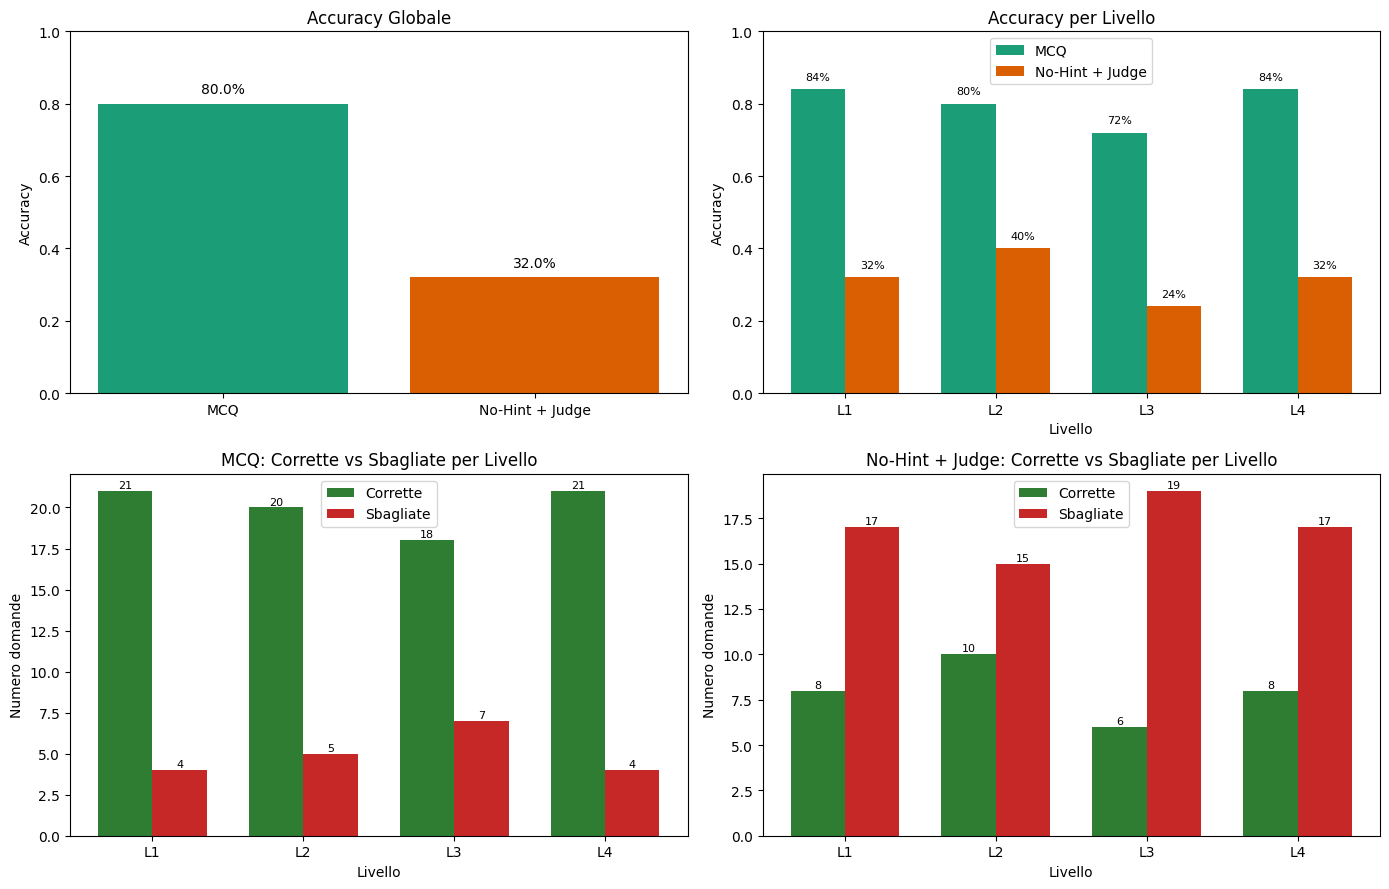

In [19]:
def level_sort_key(level_name: str) -> tuple[int, Any]:
    m = re.match(r"^L(\d+)$", str(level_name).strip().upper())
    return (0, int(m.group(1))) if m else (1, str(level_name))

all_levels = sorted(
    set(mcq_summary["by_level"].keys()) | set(no_hint_summary["by_level"].keys()),
    key=level_sort_key,
)

mcq_global_acc = mcq_summary["accuracy"] if mcq_summary["accuracy"] is not None else 0.0
no_hint_global_acc = no_hint_summary["accuracy"] if no_hint_summary["accuracy"] is not None else 0.0

mcq_level_acc = [
    (mcq_summary["by_level"].get(lvl, {}).get("accuracy") or 0.0)
    for lvl in all_levels
]
no_hint_level_acc = [
    (no_hint_summary["by_level"].get(lvl, {}).get("accuracy") or 0.0)
    for lvl in all_levels
]

mcq_correct = [mcq_summary["by_level"].get(lvl, {}).get("correct", 0) for lvl in all_levels]
mcq_wrong = [mcq_summary["by_level"].get(lvl, {}).get("wrong", 0) for lvl in all_levels]

no_hint_correct = [no_hint_summary["by_level"].get(lvl, {}).get("correct", 0) for lvl in all_levels]
no_hint_wrong = [no_hint_summary["by_level"].get(lvl, {}).get("wrong", 0) for lvl in all_levels]

x = list(range(len(all_levels)))
width = 0.36

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Global accuracy
ax = axes[0, 0]
labels = ["MCQ", "No-Hint + Judge"]
vals = [mcq_global_acc, no_hint_global_acc]
colors = ["#1b9e77", "#d95f02"]
bars = ax.bar(labels, vals, color=colors)
ax.set_ylim(0, 1)
ax.set_title("Accuracy Globale")
ax.set_ylabel("Accuracy")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.1%}", ha="center", va="bottom")

# 2) Accuracy per livello
ax = axes[0, 1]
bars_mcq = ax.bar([i - width / 2 for i in x], mcq_level_acc, width, label="MCQ", color="#1b9e77")
bars_nh = ax.bar([i + width / 2 for i in x], no_hint_level_acc, width, label="No-Hint + Judge", color="#d95f02")
ax.set_ylim(0, 1)
ax.set_xticks(x, all_levels)
ax.set_title("Accuracy per Livello")
ax.set_xlabel("Livello")
ax.set_ylabel("Accuracy")
ax.legend()
for bars in (bars_mcq, bars_nh):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h:.0%}", ha="center", va="bottom", fontsize=8)

# 3) MCQ corrette/sbagliate per livello
ax = axes[1, 0]
bars_c = ax.bar([i - width / 2 for i in x], mcq_correct, width, label="Corrette", color="#2E7D32")
bars_w = ax.bar([i + width / 2 for i in x], mcq_wrong, width, label="Sbagliate", color="#C62828")
ax.set_xticks(x, all_levels)
ax.set_title("MCQ: Corrette vs Sbagliate per Livello")
ax.set_xlabel("Livello")
ax.set_ylabel("Numero domande")
ax.legend()
for bars in (bars_c, bars_w):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05, f"{int(h)}", ha="center", va="bottom", fontsize=8)

# 4) No-Hint corrette/sbagliate per livello
ax = axes[1, 1]
bars_c = ax.bar([i - width / 2 for i in x], no_hint_correct, width, label="Corrette", color="#2E7D32")
bars_w = ax.bar([i + width / 2 for i in x], no_hint_wrong, width, label="Sbagliate", color="#C62828")
ax.set_xticks(x, all_levels)
ax.set_title("No-Hint + Judge: Corrette vs Sbagliate per Livello")
ax.set_xlabel("Livello")
ax.set_ylabel("Numero domande")
ax.legend()
for bars in (bars_c, bars_w):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05, f"{int(h)}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## Analisi Errori Rapida

### Scopo
Mostrare un campione dei casi sbagliati o in errore per debug qualitativo.

### Output
- Preview prime `TOP_K_ERRORS` per MCQ e no-hint

In [20]:
TOP_K_ERRORS = 5

mcq_error_cases = [
    r for r in mcq_results
    if r.get("error") or r.get("score") == 0
]

no_hint_error_cases = [
    r for r in no_hint_results
    if r.get("error") or r.get("final_binary_score") == 0
]

print(f"MCQ error/wrong cases: {len(mcq_error_cases)}")
for row in mcq_error_cases[:TOP_K_ERRORS]:
    print(json.dumps({
        "qid": row["qid"],
        "level": row["level"],
        "ground_truth_label": row["ground_truth_label"],
        "predicted_label": row["predicted_label"],
        "score": row["score"],
        "error": row["error"],
    }, ensure_ascii=False, indent=2))

print(f"\nNo-Hint error/wrong cases: {len(no_hint_error_cases)}")
for row in no_hint_error_cases[:TOP_K_ERRORS]:
    judge = row.get("judge_result") or {}
    print(json.dumps({
        "qid": row["qid"],
        "level": row["level"],
        "predicted_answer": row.get("predicted_answer"),
        "final_binary_score": row.get("final_binary_score"),
        "judge_matched_option": judge.get("matched_option_label"),
        "judge_justification": judge.get("justification"),
        "error": row.get("error"),
    }, ensure_ascii=False, indent=2))

MCQ error/wrong cases: 20
{
  "qid": "7",
  "level": "L3",
  "ground_truth_label": "B",
  "predicted_label": "A",
  "score": 0,
  "error": null
}
{
  "qid": "11",
  "level": "L3",
  "ground_truth_label": "D",
  "predicted_label": "A",
  "score": 0,
  "error": null
}
{
  "qid": "12",
  "level": "L4",
  "ground_truth_label": "D",
  "predicted_label": "C",
  "score": 0,
  "error": null
}
{
  "qid": "14",
  "level": "L2",
  "ground_truth_label": "D",
  "predicted_label": "C",
  "score": 0,
  "error": null
}
{
  "qid": "15",
  "level": "L3",
  "ground_truth_label": "D",
  "predicted_label": "A",
  "score": 0,
  "error": null
}

No-Hint error/wrong cases: 68
{
  "qid": "1",
  "level": "L1",
  "predicted_answer": "Gli organi tipici di un’Azienda USL sono: Consiglio di amministrazione, Direttore generale, Collegio dei dirigenti, Comitato tecnico, Commissione di vigilanza, Collegio dei revisori dei conti e, nei casi previsti, il Comitato di programmazione e il Comitato di valutazione della qual

## Conclusioni e Next Steps

### Lettura risultati
- `mcq_summary` misura performance diretta su risposte a scelta multipla.
- `no_hint_summary` misura performance su risposta aperta valutata da judge semantico.
- `comparison_summary` evidenzia differenze globali e per livello.

### Limiti
- Il judge è un LLM: utile per valutazione semantica, ma non equivalente a un gold verifier deterministico.
- Con `temperature=0` riduci varianza ma non elimini completamente effetti di prompting.

### Prossimi miglioramenti
- ripetere i run con più seed/modelli per stabilità
- aggiungere una baseline non-LLM per il judge
- esportare risultati in file in una fase successiva (se richiesto)